## Initializing data frame

#### based on karennas inference_df

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm.notebook import tqdm
tqdm.pandas(leave = False)

# from transformers import (
#     AutoTokenizer,
#     EsmTokenizer,
#     EsmForMaskedLM,
#     pipeline,
# )

from itertools import chain
import torch
import torch.nn.functional as F
import scipy

In [126]:
import pandas as pd
pref_germ_df = pd.read_json("./results/preferential_germline_1000.json", dtype=str)
pref_mut_df = pd.read_json("./results/preferential_mutated_1000.json", dtype=str)
uni_germ_df = pd.read_json("./results/uniform_germline_1000.json", dtype=str)
uni_mut_df = pd.read_json("./results/uniform_mutated_1000.json", dtype=str)
rand_germ_df = pd.read_json("./results/random_germline_1000.json", dtype=str)
rand_mut_df = pd.read_json("./results/random_mutated_1000.json", dtype=str)
m8M_germ_df = pd.read_parquet("./results/8M-F_germline_10000.parquet")
m8M_mut_df = pd.read_parquet("./results/8M-F_mutated_10000.parquet")
m35M_germ_df = pd.read_parquet("./results/35M-F_germline_10000.parquet")
m35M_mut_df = pd.read_parquet("./results/35M-F_mutated_10000.parquet")
m150M_germ_df = pd.read_parquet("./results/150M-F_germline_10000.parquet")
# m150M_mut_df = pd.read_parquet("./results/150M-F_mutated_10000.parquet")
# m350M_germ_df = pd.read_parquet("./results/350M-F_germline_10000.parquet")
# m350M_mut_df = pd.read_parquet("./results/350M-F_mutated_10000.parquet")
# m650M_germ_df = pd.read_parquet("./results/650M-F_germline_10000.parquet")
# m650M_mut_df = pd.read_parquet("./results/650M-F_mutated_10000.parquet")

pref_germ_df["model"] = "Preferential"
pref_mut_df["model"] = "Preferential"
uni_germ_df["model"] = "Uniform"
uni_mut_df["model"] = "Uniform"
rand_germ_df["model"] = "Random"
rand_mut_df["model"] = "Random"
m8M_germ_df["model"] = "8M-F"
m8M_mut_df["model"] = "8M-F"
m35M_germ_df["model"] = "35M-F"
m35M_mut_df["model"] = "35M-F"
m150M_germ_df["model"] = "150M-F"
# m150M_mut_df["model"] = "150M-F"
# m350M_germ_df["model"] = "350M-F"
# m350M_mut_df["model"] = "350M-F"
# m650M_germ_df["model"] = "650M-F"
# m650M_mut_df["model"] = "650M-F"

pref_germ_df["data_type"] = "Germline"
pref_mut_df["data_type"] = "Mutated"
uni_germ_df["data_type"] = "Germline"
uni_mut_df["data_type"] = "Mutated"
rand_germ_df["data_type"] = "Germline"
rand_mut_df["data_type"] = "Mutated"
m8M_germ_df["data_type"] = "Germline"
m8M_mut_df["data_type"] = "Mutated"
m35M_germ_df["data_type"] = "Germline"
m35M_mut_df["data_type"] = "Mutated"
m150M_germ_df["data_type"] = "Germline"
# m150M_mut_df["data_type"] = "Mutated"
# m350M_germ_df["data_type"] = "Germline"
# m350M_mut_df["data_type"] = "Mutated"
# m650M_germ_df["data_type"] = "Germline"
# m650M_mut_df["data_type"] = "Mutated"

inference_df = pd.concat([pref_germ_df, uni_germ_df, pref_mut_df, uni_mut_df, 
                        rand_germ_df, rand_mut_df,
                         m8M_germ_df, m8M_mut_df, m35M_germ_df, m35M_mut_df, m150M_germ_df], 
                         join="inner")




inference_df

,sequence,cdr_mask,heavy,light,cdr_indices,prediction,accuracy_by_region,score_by_region,loss_by_region,perplexity_by_region,score,loss,perplexity,model,data_type
0,QVQLQESGPGLVKPSQTLSLTCTVSGGSISSGSYYWSWIRQPAGKG...,0000000000000000000000000111111111100000000000...,QVQLQESGPGLVKPSQTLSLTCTVSGGSISSGSYYWSWIRQPAGKG...,QTVVTQEPSFSVSPGGTVTLTCGLSSGSVSTSYYPSWYQQTPGQAP...,"[0, 25, 35, 52, 59, 97, 116, 127, 152, 161, 17...",QVQLQESGPGLVKPSQTLSLTCTVSGGSISSGSYYWSWIRQPAGKG...,"[1.0, 1.0, 1.0, 1.0, 1.0, 0.8947368421, 1.0, 1...","[0.9999622011, 0.9997491837, 0.9981532167, 0.9...","[1.657e-05, 0.0001516225, 2.26495e-05, 0.00017...","[1.0000165701, 1.0001516342, 1.0000226498, 1.0...","[0.99994874, 0.9999278784000001, 0.9999694824,...","[5.1258700000000004e-05, 7.2119e-05, 3.05171e-...","[1.00005126, 1.0000721216, 1.0000305176, 1.000...",Preferential,Germline
1,EVQLVESGGGLVKPGGSLRLSCAASGFTFSSYSMNWVRQAPGKGLE...,0000000000000000000000000111111110000000000000...,EVQLVESGGGLVKPGGSLRLSCAASGFTFSSYSMNWVRQAPGKGLE...,DIVMTQSPLSLPVTPGEPASISCRSSQSLLHSNGYNYLDWYLQKPG...,"[0, 25, 33, 50, 58, 96, 117, 128, 154, 165, 18...",EVQLVESGGGLVKPGGSLRLSCAASGFTFSSYSMNWVRQAPGKGLE...,"[1.0, 1.0, 1.0, 1.0, 1.0, 0.8571428571, 1.0, 1...","[0.9999891996, 0.9999404848000001, 0.999987728...","[6.5565e-06, 5.4417400000000005e-05, 3.4571000...","[1.0000065565, 1.000054419, 1.0000034571, 1.00...","[0.999984622, 0.9999904633000001, 0.9999850988...","[1.53779e-05, 9.5367e-06, 1.49011e-05, 3.20668...","[1.000015378, 1.0000095367, 1.0000149012, 1.00...",Preferential,Germline
2,EVQLVESGGGLVQPGGSLKLSCAASGFTFSGSAMHWVRQASGKGLE...,0000000000000000000000000111111110000000000000...,EVQLVESGGGLVQPGGSLKLSCAASGFTFSGSAMHWVRQASGKGLE...,EIVLTQSPATLSLSPGERATLSCRASQSVSSYLAWYQQKPGQAPRL...,"[0, 25, 33, 50, 60, 98, 117, 128, 154, 160, 17...",EVQLVESGGGLVQPGGSLKLSCAASGFTFSGSAMHWVRQASGKGLE...,"[1.0, 1.0, 1.0, 1.0, 1.0, 0.6315789474, 1.0, 1...","[0.9985284877, 0.999972865, 0.9999752886000001...","[6.0797e-06, 2.5272e-05, 5.4836e-06, 1.806e-05...","[1.0000060797, 1.0000252724, 1.0000054836, 1.0...","[0.9999821186000001, 0.9999939203, 0.999985098...","[1.78812e-05, 6.0797e-06, 1.49011e-05, 9.5367e...","[1.0000178814, 1.0000060797, 1.0000149012, 1.0...",Preferential,Germline
3,EVQLVQSGAEVKKPGESLKISCKGSGYSFTSYWIGWVRQMPGKGLE...,0000000000000000000000000111111110000000000000...,EVQLVQSGAEVKKPGESLKISCKGSGYSFTSYWIGWVRQMPGKGLE...,SYELTQPPSVSVSPGQTARITCSGDALPKQYAYWYQQKPGQAPVLV...,"[0, 25, 33, 50, 58, 96, 110, 121, 146, 152, 16...",EVQLVQSGAEVKKPGESLKISCKGSGYSFTSYWIGWVRQMPGKGLE...,"[1.0, 1.0, 1.0, 1.0, 1.0, 0.5, 1.0, 1.0, 1.0, ...","[0.9998977685, 0.9986850843, 0.9998514407, 0.9...","[4.7325000000000005e-05, 0.0003194192, 4.38681...","[1.0000473261, 1.0003194809, 1.000043869, 1.00...","[0.9999521971, 0.9999557734000001, 0.999902606...","[4.78018e-05, 4.42257e-05, 9.73892e-05, 1.9550...","[1.0000478029, 1.0000442266, 1.000097394, 1.00...",Preferential,Germline
4,EVQLVESGGGLVQPGGSLRLSCAASGFTFSSYSMNWVRQAPGKGLE...,0000000000000000000000000111111110000000000000...,EVQLVESGGGLVQPGGSLRLSCAASGFTFSSYSMNWVRQAPGKGLE...,SSELTQDPAVSVALGQTVRITCQGDSLRSYYASWYQQKPGQAPVLV...,"[0, 25, 33, 50, 58, 96, 116, 127, 152, 158, 17...",EVQLVESGGGLVQPGGSLRLSCAASGFTFSSYSMNWVRQAPGKGLE...,"[1.0, 1.0, 1.0, 1.0, 1.0, 0.5, 1.0, 1.0, 1.0, ...","[0.9999899054, 0.9999507666, 0.999988506800000...","[7.987e-06, 3.74906e-05, 5.0068e-06, 5.8112800...","[1.000007987, 1.0000374913, 1.0000050068, 1.00...","[0.9999884367, 0.9999916553, 0.9999855757, 0.9...","[1.15632e-05, 8.3446e-06, 1.44242e-05, 1.43050...","[1.0000115633, 1.0000083447, 1.0000144243, 1.0...",Preferential,Germline
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,QVQLVESGGGVVQPGRSLRLSCAASGFTFSSYAMHWVRQAPGKGLE...,0000000000000000000000000111111110000000000000...,QVQLVESGGGVVQPGRSLRLSCAASGFTFSSYAMHWVRQAPGKGLE...,DIQLTQSPSFLSASVGDRVTITCRASQGISSYLAWYQQKPGKAPKL...,"[0, 25, 33, 50, 58, 96, 115, 126, 152, 158, 17...",QVQLVESGGGVVQPGRSLRLSCAASGFTFSSYAMHWVRQAPGKGLE...,"[1.0, 1.0, 1.0,

In [127]:
import pandas as pd
import numpy as np
# import blosum_metric 
# from blosum_metric import new_scores
import condensed_blosum_metric
from condensed_blosum_metric import new_scores

# sequencelist = list(inference_df["sequence"])
inferredlist = list(inference_df["prediction"])
region = list(inference_df["cdr_mask"])
filelist = list(inference_df["model"])
file_type_list = list(inference_df["data_type"])

heavychainlist = list(inference_df["heavy"])
lightchainlist = list(inference_df["light"])
        # find = new_scores(sequencelist[i], inferredlist[i][len(heavychainlist[i]):], region[i][len(heavychainlist[i]):])

sequencelist = heavychainlist

sum_run_avg = []
sum_run_frw_avg = []
sum_run_cdr1_avg = []
sum_run_cdr2_avg = []
sum_run_cdr3_avg = []

scores_list = []

for i in range (0, len(sequencelist)):
    find = new_scores(sequencelist[i], inferredlist[i], region[i])
    # find = new_scores(sequencelist[i], inferredlist[i][len(heavychainlist[i]):], region[i][len(heavychainlist[i]):])


    scores_list.append({
        "Seq ID": sequencelist[i],
        "Region": "Framework",
        "Metric": find[1],
        "Model": filelist[i],
        "Data Type": file_type_list[i],
        "Median": find[6]
    })

    scores_list.append({
        "Seq ID": sequencelist[i],
        "Region": "CDR1",
        "Metric": find[2],
        "Model": filelist[i],
        "Data Type": file_type_list[i],
        "Median": find[7]

    })

    scores_list.append({
        "Seq ID": sequencelist[i],
        "Region": "CDR2",
        "Metric": find[3],
        "Model": filelist[i],
        "Data Type": file_type_list[i],
        "Median": find[8]

    })

    scores_list.append({
        "Seq ID": sequencelist[i],
        "Region": "CDR3",
        "Metric": find[4],
        "Model": filelist[i],
        "Data Type": file_type_list[i],
        "Median": find[9]

    })

    sum_run_avg.append(find[0])
    sum_run_frw_avg.append(find[1])
    sum_run_cdr1_avg.append(find[2])
    sum_run_cdr2_avg.append(find[3])
    sum_run_cdr3_avg.append(find[4])

scores_df = pd.DataFrame(scores_list)

In [128]:
scores_df.head()

,Seq ID,Region,Metric,Model,Data Type,Median
0,QVQLQESGPGLVKPSQTLSLTCTVSGGSISSGSYYWSWIRQPAGKG...,Framework,1.000000,Preferential,Germline,1.0
1,QVQLQESGPGLVKPSQTLSLTCTVSGGSISSGSYYWSWIRQPAGKG...,CDR1,1.000000,Preferential,Germline,1.0
2,QVQLQESGPGLVKPSQTLSLTCTVSGGSISSGSYYWSWIRQPAGKG...,CDR2,1.000000,Preferential,Germline,1.0
3,QVQLQESGPGLVKPSQTLSLTCTVSGGSISSGSYYWSWIRQPAGKG...,CDR3,0.917295,Preferential,Germline,1.0
4,EVQLVESGGGLVKPGGSLRLSCAASGFTFSSYSMNWVRQAPGKGLE...,Framework,1.000000,Preferential,Germline,1.0


In [113]:
heavy_pre_df = []

for i in range (0, 15):
    
    heavy_pre_df.append({
            "Seq": list(inference_df["heavy"])[i],
            "Prediction": list(inference_df["prediction"])[i],
            "cdr_mask": list(inference_df["cdr_mask"])[i],
            "Scores": list(inference_df["score"])[i],
            "Model": list(inference_df["model"])[i],
            "Data Type": list(inference_df["data_type"])[i]
        })

heavy_df = pd.DataFrame(heavy_pre_df)
heavy_df.head()

,Seq,Prediction,cdr_mask,Scores,Model,Data Type
0,QVQLQESGPGLVKPSQTLSLTCTVSGGSISSGSYYWSWIRQPAGKG...,QVQLQESGPGLVKPSQTLSLTCTVSGGSISSGSYYWSWIRQPAGKG...,0000000000000000000000000111111111100000000000...,"[0.99994874, 0.9999278784000001, 0.9999694824,...",Preferential,Germline
1,EVQLVESGGGLVKPGGSLRLSCAASGFTFSSYSMNWVRQAPGKGLE...,EVQLVESGGGLVKPGGSLRLSCAASGFTFSSYSMNWVRQAPGKGLE...,0000000000000000000000000111111110000000000000...,"[0.999984622, 0.9999904633000001, 0.9999850988...",Preferential,Germline
2,EVQLVESGGGLVQPGGSLKLSCAASGFTFSGSAMHWVRQASGKGLE...,EVQLVESGGGLVQPGGSLKLSCAASGFTFSGSAMHWVRQASGKGLE...,0000000000000000000000000111111110000000000000...,"[0.9999821186000001, 0.9999939203, 0.999985098...",Preferential,Germline
3,EVQLVQSGAEVKKPGESLKISCKGSGYSFTSYWIGWVRQMPGKGLE...,EVQLVQSGAEVKKPGESLKISCKGSGYSFTSYWIGWVRQMPGKGLE...,0000000000000000000000000111111110000000000000...,"[0.9999521971, 0.9999557734000001, 0.999902606...",Preferential,Germline
4,EVQLVESGGGLVQPGGSLRLSCAASGFTFSSYSMNWVRQAPGKGLE...,EVQLVESGGGLVQPGGSLRLSCAASGFTFSSYSMNWVRQAPGKGLE...,0000000000000000000000000111111110000000000000...,"[0.9999884367, 0.9999916553, 0.9999855757, 0.9...",Preferential,Germline


In [45]:
heavy_df["Scores"][0]

'[0.9999622011, 0.9997491837, 0.9981532167, 0.9997713992, 0.9999357493000001, 0.7688741566, 0.9999347763, 0.9999746442, 0.9998870624, 0.9999288110000001, 0.9996902545, 0.9998121841000001, 0.952703315, 0.9986712754]'

In [41]:
heavy_df["cdr_mask"][0]

'000000000000000000000000011111111110000000000000000022222220000000000000000000000000000000000000033333333333333333330000000000000000000000000000000000001111111110000000000000000022200000000000000000000000000000000000033333333330000000000'

In [91]:
model_stats = {
    
    "uniform_germline": "./results/uniform_germline_1000.json",
    "preferential_germline": "./results/preferential_germline_1000.json",
    "uniform_mutated": "./results/uniform_mutated_1000.json",
    "preferential_mutated": "./results/preferential_mutated_1000.json",
    
    "random_germline": "./results/random_germline_1000.json",
    "random_mutated": "./results/random_mutated_1000.json",
    "8M-F_germline": "./results/8M-F_germline_10000.parquet",
    "8M-F_mutated": "./results/8M-F_mutated_10000.parquet",
    "35M-F_germline": "./results/35M-F_germline_10000.parquet",
    "35M-F_mutated": "./results/35M-F_mutated_10000.parquet",
    "150M-F_germline": "./results/150M-F_germline_10000.parquet",


}

In [92]:
# aggregating and pivoting stats for plotting
def make_stats_df(uniform_path, preferential_path, random_path, size_path8m, size_path35m, size_path150m):

    # make local dict for this function only
    model_dict = {
        "uniform": uniform_path,
        "preferential": preferential_path,
        
        "random": random_path,
        "Psize8m": size_path8m,
        "Psize35m": size_path35m,
        "Psize150m": size_path150m
        
    }

    # pivoting data
    stats_list = []

    for _id, data_path in tqdm(model_dict.items()):
        print("1: ", _id[0])
        if _id[0] == "P":
            print(_id[0])
            model_df = pd.read_parquet(data_path)
        else:
            model_df = pd.read_json(data_path)
        model_df = model_df[model_df["cdr_indices"].map(len) == 15] # remove rows without cdr2, would change regional split of stats and not sure how to fix without redoing alignment
        acc_df = pd.DataFrame(list(model_df["accuracy_by_region"]))
        score_df = pd.DataFrame(list(model_df["score_by_region"]))
        loss_df = pd.DataFrame(list(model_df["loss_by_region"]))
        perplexity_df = pd.DataFrame(list(model_df["perplexity_by_region"]))
        
        # the way each metrics' df is made, they should refer to the same instance at the same indices --> important for paired t-test
        for n in acc_df.columns:
            for i in range(len(acc_df)):
                stats_list.append({
                    "seq_id": i,
                    "region": n,
                    "model_id": _id,
                    "accuracy": acc_df.iloc[i, n],
                    "score": score_df.iloc[i, n],
                    "loss": loss_df.iloc[i, n],
                    "perplexity": perplexity_df.iloc[i, n],
                })

    # make into dataframe with renamed regions for plotting
    stats_df = pd.DataFrame(stats_list)
    stats_df.replace({"region": {0:"FRH1", 1:"CDRH1", 2:"FRH2", 3:"CDRH2", 4:"FRH3", 5:"CDRH3", 6:"FRH4",
                                7:"FRL1", 8:"CDRL1", 9:"FRL2", 10:"CDRL2", 11:"FRL3", 12:"CDRL3", 13:"FRL4"}}, inplace=True)
    return stats_df

In [93]:
# statistical significance
# dependent t-test --> each model performed inference on the same 1000 sequences, so samples are paired
def dep_ttest(data, col_name, model_1, model_2, save_tstats=False, alternative="two-sided"):
    # split comparisons by Ab region
    regions = data["region"].unique()

    # perform dependent t-test
    pvals = []
    if save_tstats:
        tstats = []
    for r in regions:
        stat, pval = scipy.stats.ttest_rel(
            data[(data["region"] == r) & (data["model_id"] == model_1)][col_name],
            data[(data["region"] == r) & (data["model_id"] == model_2)][col_name],
            alternative=alternative,
        )
        pvals.append(pval)
        if save_tstats:
            tstats.append(stat)

    return (pvals, tstats) if save_tstats else pvals

# for plotting, change p-values into asterisks, includes argument for multiple testing correction
def convert_pvalue_to_asterisks(pvalue, n_tests = 1):
    if pvalue <= 0.0001/n_tests:
        return "****"
    elif pvalue <= 0.001/n_tests:
        return "***"
    elif pvalue <= 0.01/n_tests:
        return "**"
    elif pvalue <= 0.05/n_tests:
        return "*"
    return "" #"ns"

In [108]:
m_data.head()

,seq_id,region,model_id,accuracy,score,loss,perplexity
0,0,FRH1,uniform,1.00,0.999982,0.000008,1.000008
1,1,FRH1,uniform,0.96,0.954889,0.026284,1.026633
2,2,FRH1,uniform,0.96,0.987918,0.006150,1.006169
3,3,FRH1,uniform,0.92,0.932192,0.022272,1.022522
4,4,FRH1,uniform,1.00,0.979391,0.013016,1.013101


  0%|          | 0/6 [00:00<?, ?it/s]

1:  u
1:  p
1:  r
1:  P
P
1:  P
P
1:  P
P


  0%|          | 0/6 [00:00<?, ?it/s]

1:  u
1:  p
1:  r
1:  P
P
1:  P
P
1:  P
P


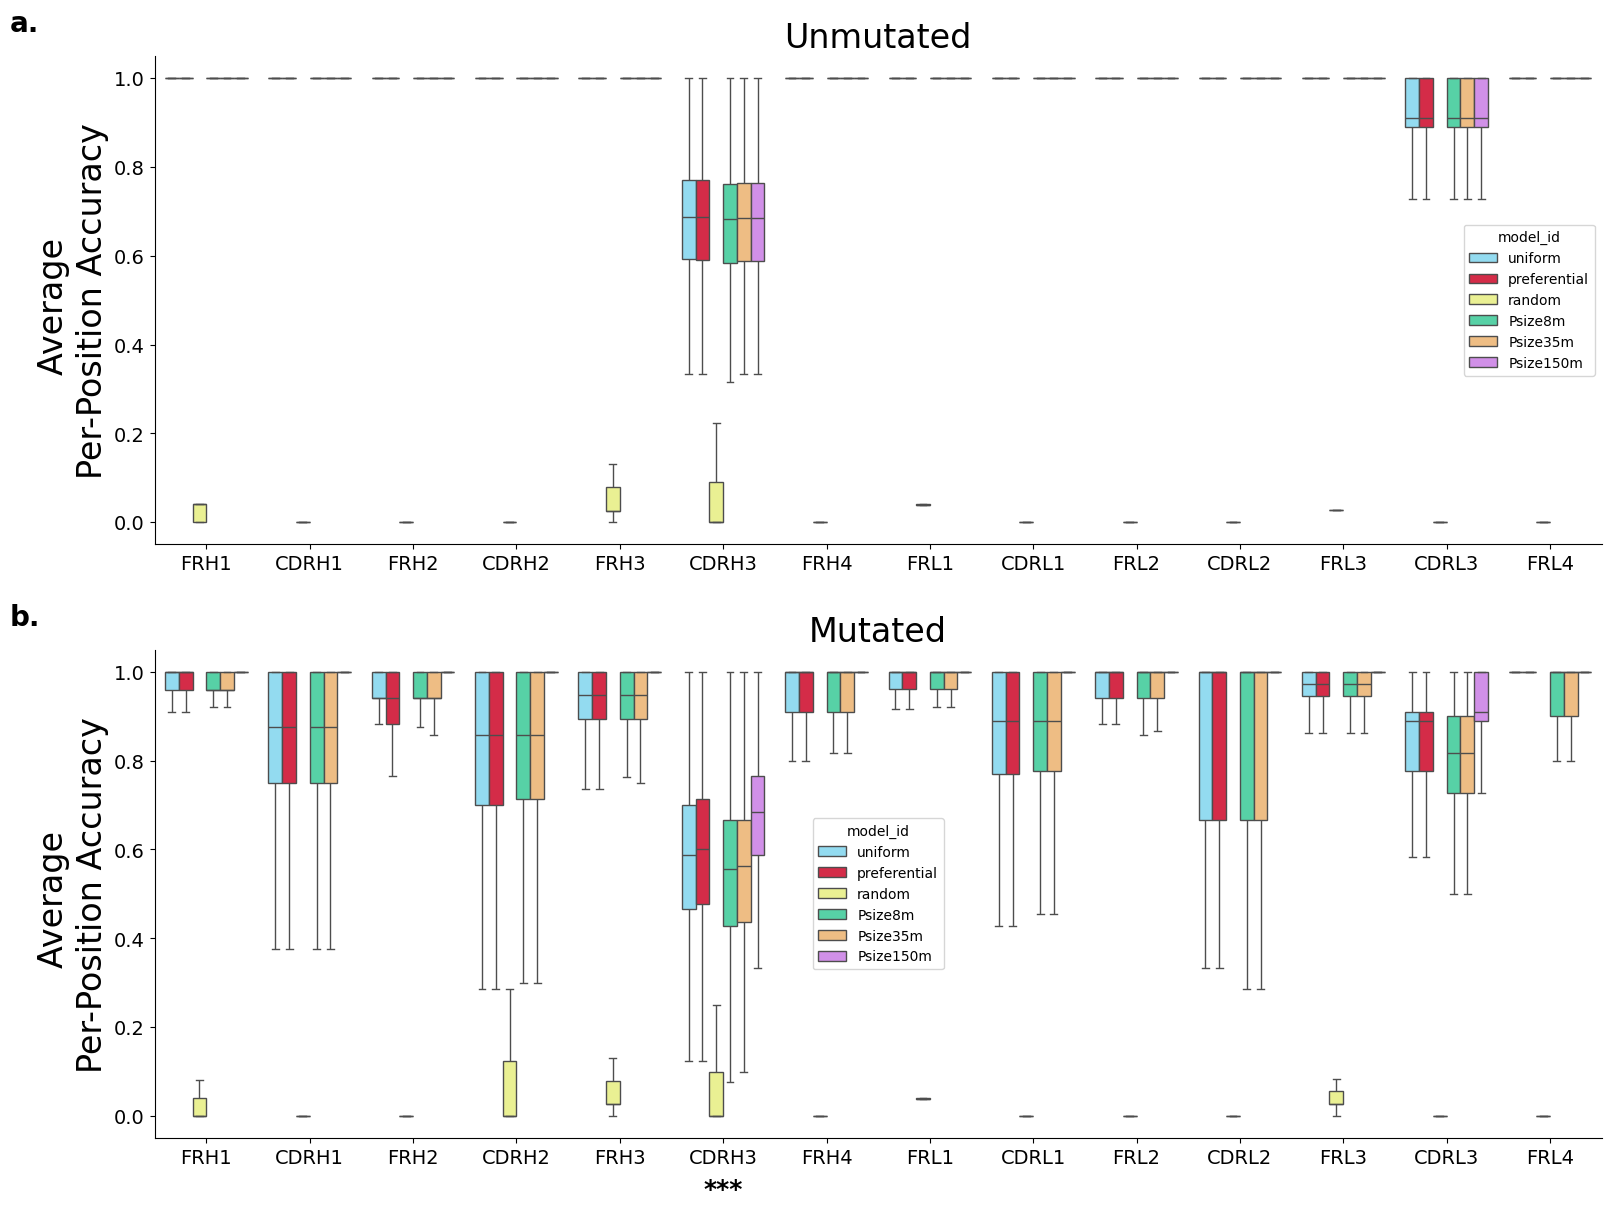

In [111]:
# consolidate stats and calculate statistical significance 
# note: can replace "accuracy" with a different inference metric ("score", "loss", "perplexity")
g_data = make_stats_df(model_stats["uniform_germline"], model_stats["preferential_germline"], model_stats["random_germline"], model_stats["8M-F_germline"], 
                       model_stats["35M-F_germline"], model_stats["150M-F_germline"])
g_pvals = dep_ttest(g_data, "accuracy", "uniform", "preferential")
m_data = make_stats_df(model_stats["uniform_mutated"], model_stats["preferential_mutated"], model_stats["random_mutated"], model_stats["8M-F_mutated"],
                       model_stats["35M-F_mutated"], model_stats["150M-F_germline"])
m_pvals = dep_ttest(m_data, "accuracy", "uniform", "preferential")

plots = {
    "a.": {
        "title": "Unmutated",
        "data": g_data,
        "pvals": g_pvals,
        "pval_offset": 0.15,
    },
    "b.": {
        "title": "Mutated",
        "data": m_data,
        "pvals": m_pvals,
        "pval_offset": -0.18,
    },
}

# plotting
fig, ax = plt.subplot_mosaic([['a.'], ['b.'],],
                              layout='constrained',
                              figsize=(16, 12),
                              gridspec_kw={"wspace": 0.05, "hspace": 0.05},
                             )
for label, x in plots.items():
    title = x["title"]
    data = x["data"]
    pvals = x["pvals"]
    offset = x["pval_offset"]

    # main plot
    sns.boxplot(x="region", y="accuracy", hue="model_id", 
              data=data, ax=ax[label], 
              palette=["#84E3FF", "#F01035", "#F8FF83", "#42e6ac", "#FFBE73", "#D881F7"], 
              showfliers=False)
    
    # p-values (multiple testing with 14 regions
    asterisks = [convert_pvalue_to_asterisks(p, len(pvals)) for p in pvals]
    for idx, p in enumerate(asterisks):
        ax[label].text(x=idx, y=offset, s=p, 
                       ha="center", fontsize=18, weight="bold")

    # labels
    ax[label].set_title(title, fontsize=24)
    ax[label].set_xlabel("", size=24)
    ax[label].set_ylabel("Average \nPer-Position Accuracy", size=24)
    ax[label].tick_params(labelsize=14)
    # plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0, title='Model')
    # ax[label].legend(handles=ax[label].get_legend_handles_labels()[0], 
    #                  labels = model_id,
    #                  loc = "lower left",
    #                  title="Model", title_fontsize=14, fontsize=12)
    ax[label].annotate(label, xy=(-0.1, 1.05), xycoords="axes fraction", 
                       fontsize=20, weight="bold")

sns.despine()
plt.savefig("./results/inference.png", bbox_inches='tight')

## Plots

## histograms

### regional histogram

/tmp/ipykernel_499/1035984448.py:9: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  hist_pref = plt.hist(scores_df[scores_df["Data Type"] == data_type][scores_df["Model"] == "Preferential"][scores_df["Region"] == reg]["Metric"],
/tmp/ipykernel_499/1035984448.py:9: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  hist_pref = plt.hist(scores_df[scores_df["Data Type"] == data_type][scores_df["Model"] == "Preferential"][scores_df["Region"] == reg]["Metric"],
/tmp/ipykernel_499/1035984448.py:12: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  hist_unif = plt.hist(scores_df[scores_df["Data Type"] == data_type][scores_df["Model"] == "Uniform"][scores_df["Region"] == reg]["Metric"],
/tmp/ipykernel_499/1035984448.py:12: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  hist_unif = plt.hist(scores_df[scores_df["Data Type"] == data_type][scores_df["Model"] == "Uniform"][scores_df["

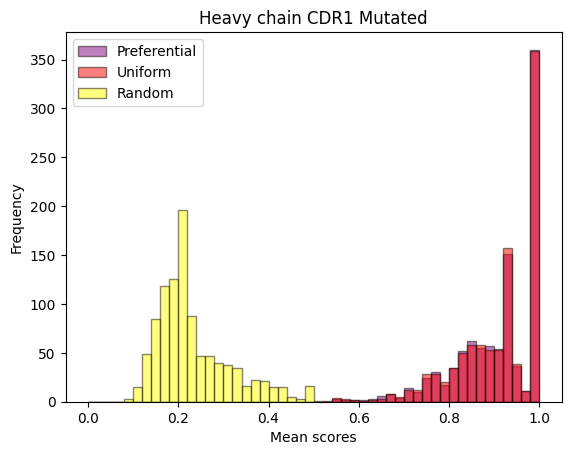

In [117]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

reg = "CDR3"
data_type = "Mutated"
chain_type = "Heavy"

hist_pref = plt.hist(scores_df[scores_df["Data Type"] == data_type][scores_df["Model"] == "Preferential"][scores_df["Region"] == reg]["Metric"], 
        label = "Preferential", range = [0,1], bins=50, 
        color = "purple", alpha = 0.5, edgecolor = "#140700")
hist_unif = plt.hist(scores_df[scores_df["Data Type"] == data_type][scores_df["Model"] == "Uniform"][scores_df["Region"] == reg]["Metric"], 
        label = "Uniform", alpha = 0.5, range = [0,1], bins=50, 
        color = "red", edgecolor = "#140700")
hist_rand = plt.hist(scores_df[scores_df["Data Type"] == data_type][scores_df["Model"] == "Random"][scores_df["Region"] == reg]["Metric"], 
        label = "Random", alpha = 0.5, range = [0,1], bins=50, 
        color = "yellow", edgecolor = "#140700")

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0, title='Model')
plt.title(f"{chain_type} chain {reg} {data_type}")
plt.ylabel("Frequency")
plt.xlabel("Mean scores")
plt.legend()

# scores_df[scores_df["Data Type"] == "Germline"][scores_df["Model"] == "Preferential"][scores_df["Region"] == "Framework"]


/tmp/ipykernel_499/1979680226.py:9: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  hist_pref = plt.hist(scores_df[scores_df["Data Type"] == data_type][scores_df["Model"] == "8M-F"][scores_df["Region"] == reg]["Metric"],
/tmp/ipykernel_499/1979680226.py:9: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  hist_pref = plt.hist(scores_df[scores_df["Data Type"] == data_type][scores_df["Model"] == "8M-F"][scores_df["Region"] == reg]["Metric"],
/tmp/ipykernel_499/1979680226.py:12: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  hist_unif = plt.hist(scores_df[scores_df["Data Type"] == data_type][scores_df["Model"] == "35M-F"][scores_df["Region"] == reg]["Metric"],
/tmp/ipykernel_499/1979680226.py:12: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  hist_unif = plt.hist(scores_df[scores_df["Data Type"] == data_type][scores_df["Model"] == "35M-F"][scores_df["Region"] == reg]["Me

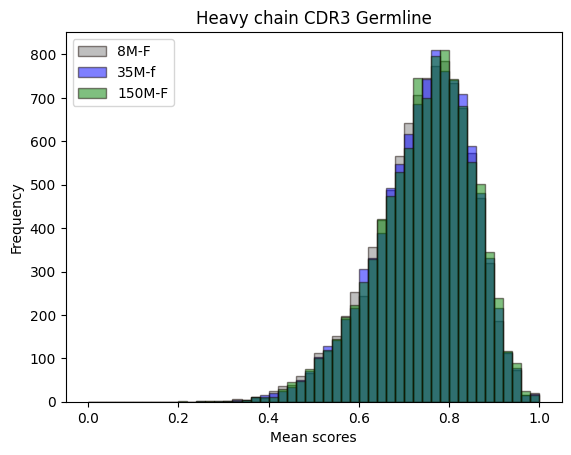

In [135]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

reg = "CDR3"
data_type = "Germline"
chain_type = "Heavy"

hist_pref = plt.hist(scores_df[scores_df["Data Type"] == data_type][scores_df["Model"] == "8M-F"][scores_df["Region"] == reg]["Metric"], 
        label = "8M-F", range = [0,1], bins=50, 
        color = "grey", alpha = 0.5, edgecolor = "#140700")
hist_unif = plt.hist(scores_df[scores_df["Data Type"] == data_type][scores_df["Model"] == "35M-F"][scores_df["Region"] == reg]["Metric"], 
        label = "35M-f", alpha = 0.5, range = [0,1], bins=50, 
        color = "blue", edgecolor = "#140700")
hist_rand = plt.hist(scores_df[scores_df["Data Type"] == data_type][scores_df["Model"] == "150M-F"][scores_df["Region"] == reg]["Metric"], 
        label = "150M-F", alpha = 0.5, range = [0,1], bins=50, 
        color = "green", edgecolor = "#140700")

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0, title='Model')
plt.title(f"{chain_type} chain {reg} {data_type}")
plt.ylabel("Frequency")
plt.xlabel("Mean scores")
plt.legend()

# scores_df[scores_df["Data Type"] == "Germline"][scores_df["Model"] == "Preferential"][scores_df["Region"] == "Framework"]


In [134]:
scores_df["Model"].unique()

<ArrowStringArray>
['Preferential', 'Uniform', 'Random', '8M-F', '35M-F', '150M-F']
Length: 6, dtype: str

### non regional/whole sequence histogram

## Boxplots

12000


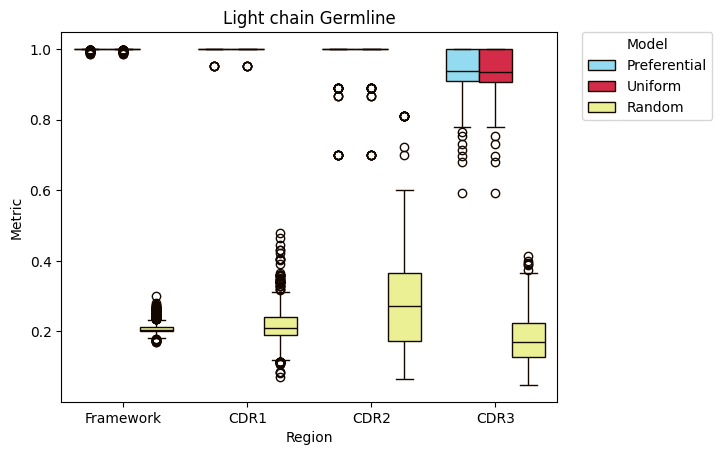

,Seq ID,Region,Metric,Model,Data Type,Median
0,QTVVTQEPSFSVSPGGTVTLTCGLSSGSVSTSYYPSWYQQTPGQAP...,Framework,1.000000,Preferential,Germline,1.0000
1,QTVVTQEPSFSVSPGGTVTLTCGLSSGSVSTSYYPSWYQQTPGQAP...,CDR1,1.000000,Preferential,Germline,1.0000
2,QTVVTQEPSFSVSPGGTVTLTCGLSSGSVSTSYYPSWYQQTPGQAP...,CDR2,1.000000,Preferential,Germline,1.0000
3,QTVVTQEPSFSVSPGGTVTLTCGLSSGSVSTSYYPSWYQQTPGQAP...,CDR3,1.000000,Preferential,Germline,1.0000
4,DIVMTQSPLSLPVTPGEPASISCRSSQSLLHSNGYNYLDWYLQKPG...,Framework,1.000000,Preferential,Germline,1.0000
...,...,...,...,...,...,...
19995,EIVMTQSPATLSVSPGERATLSCRASQSVSSNLAWYQQKPGQAPRL...,CDR3,0.089130,Random,Germline,0.1000
19996,EIVLTQSPATLSLSPGERATLSCRASQSVSSYLAWYQQKPGQAPRL...,Framework,0.209155,Random,Germline,0.1429
19997,EIVLTQSPATLSLSPGERATLSCRASQSVSSYLAWYQQKPGQAPRL...,CDR1,0.207133,Random,Germline,0.2857
19998,EIVLTQSPATLSLSPGERATLSCRASQSVSSYLAWYQQKPGQAPRL...,CDR2,0.271433,Random,Germline,0.2857


In [35]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

print(len(scores_df[scores_df["Data Type"]== "Germline"]))

chain_type = "Light"
data_type = "Germline"
calculation_type = "Metric"

plot = sns.boxplot(x = "Region", y = calculation_type, data = scores_df[scores_df["Data Type"] == data_type], hue="Model", 
        palette=["#84E3FF", "#F01035", "#F8FF83"], linecolor = "#140700").set(title = f"{chain_type} chain {data_type}")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0, title='Model')
plt.ylabel(calculation_type)
plt.show()
scores_df[scores_df["Data Type"]== data_type]